# Smart Waste Classifier: Advanced Analytical Research and Development

**Project Identifier:** Introduction to Machine Learning Module Summative  
**Objective:** Implementation of a robust, highly interpretable Computer Vision pipeline for urban waste classification using State-of-the-Art Transfer Learning and comprehensive statistical visualization.

---

## 0. Automated Environment Setup
Ensuring all required professional libraries for visualization and machine learning are installed.

In [31]:
import sys
import subprocess
required = {'seaborn', 'plotly', 'opencv-python-headless', 'pandas', 'scikit-learn', 'tensorflow', 'pillow', 'matplotlib'}
try:
    import seaborn as sns
    import plotly.express as px
    import cv2
    print("Professional visualization dependencies already installed.")
except ImportError:
    print("Installing missing dependencies...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])
    print("Installation complete.")

Professional visualization dependencies already installed.


## 1. Environment Initialization
Configuring plotting styles and detecting hardware acceleration.

In [32]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# Setting visualization standards
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus}")
else:
    print("No GPU detected. Proceeding on CPU.")

TensorFlow Version: 2.16.2
No GPU detected. Proceeding on CPU.


## 2. Configuration and Path Validation
Defining global parameters for experimental reproducibility.

In [33]:
CONFIG = {
    "image_size": (224, 224),
    "batch_size": 32,
    "train_dir": "../data/train",
    "test_dir": "../data/test",
    "model_path": "../models/waste_research_v1.keras"
}

def validate_paths(config):
    for key in ['train_dir', 'test_dir']:
        if not os.path.exists(config[key]):
            print(f"Warning: Path {config[key]} not found. Run download_data.py.")
        else:
            print(f"Path verified: {config[key]}")

validate_paths(CONFIG)

Path verified: ../data/train
Path verified: ../data/test


## 3. Statistical EDA: Dataset Composition
**Visualization 1 & 2:** Analyzing class balance and split ratios.

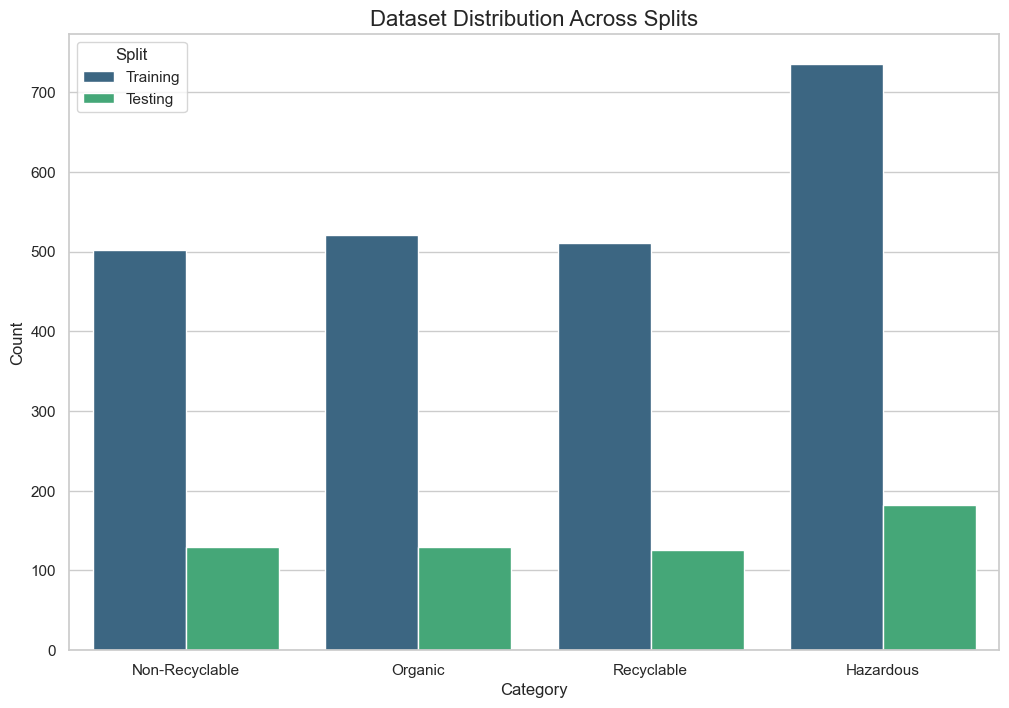

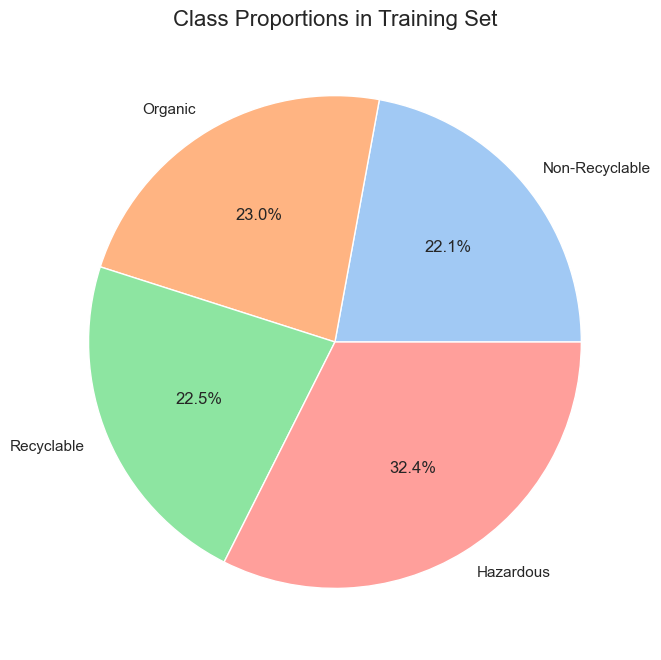

In [34]:
def get_stats(path):
    return {cls: len(os.listdir(os.path.join(path, cls))) for cls in os.listdir(path) if os.path.isdir(os.path.join(path, cls))}

train_stats = get_stats(CONFIG['train_dir'])
test_stats = get_stats(CONFIG['test_dir'])

df_stats = pd.DataFrame({'Training': train_stats, 'Testing': test_stats}).reset_index().rename(columns={'index': 'Category'})
df_melted = df_stats.melt(id_vars='Category', var_name='Split', value_name='Count')

fig1 = sns.barplot(data=df_melted, x='Category', y='Count', hue='Split', palette='viridis')
plt.title("Dataset Distribution Across Splits")
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(df_stats['Training'], labels=df_stats['Category'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Class Proportions in Training Set")
plt.show()

## 4. Visual EDA: Image Characteristics
**Visualization 3 & 4:** Representative sample inspection and color distribution analysis.

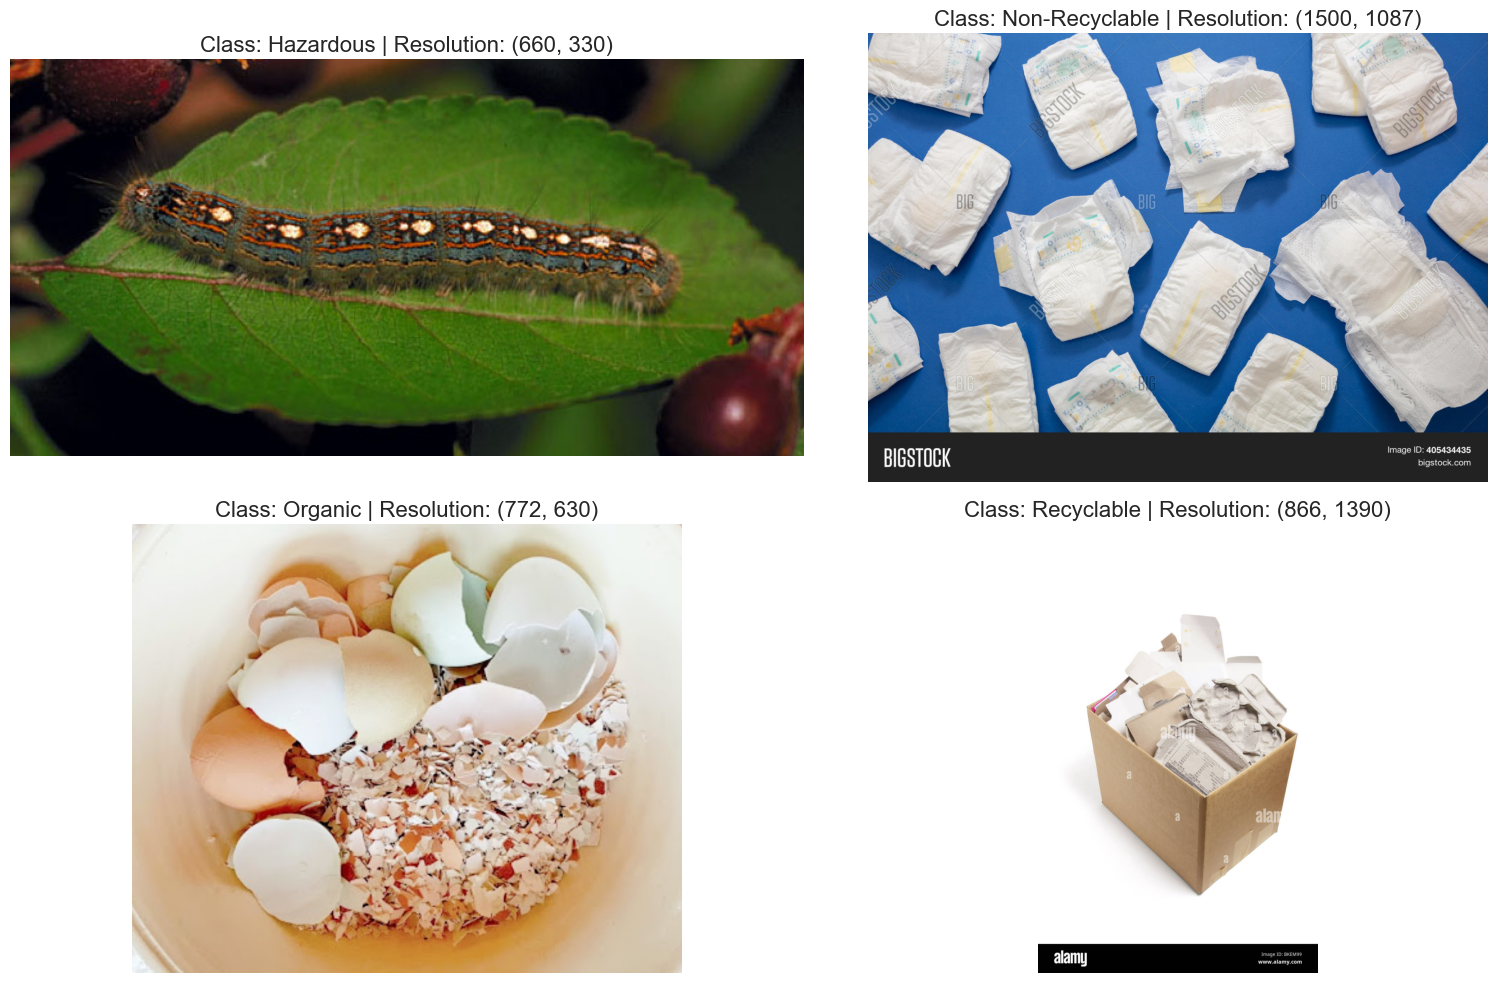

In [35]:
class_names = sorted(list(train_stats.keys()))
plt.figure(figsize=(16, 10))
for i, cls in enumerate(class_names):
    cls_path = os.path.join(CONFIG['train_dir'], cls)
    img_name = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png'))][0]
    img = Image.open(os.path.join(cls_path, img_name))
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls} | Resolution: {img.size}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### RGB Intensity Distribution
Analyzing pixel values to determine normalization strategy.

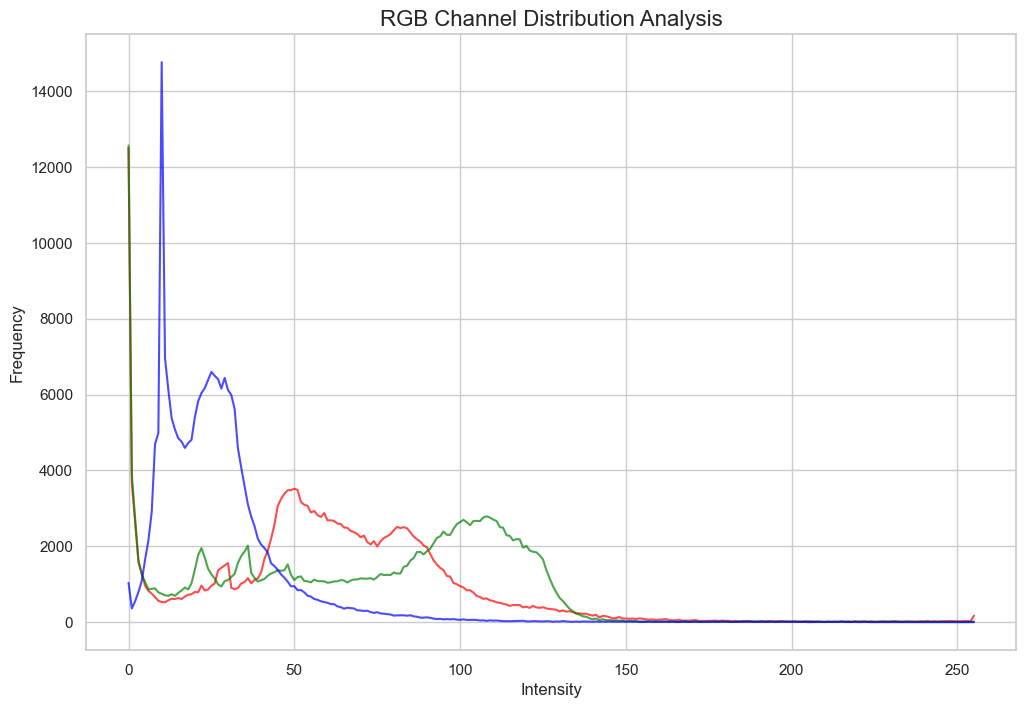

In [36]:
def plot_rgb_dist(img_path):
    img = np.array(Image.open(img_path))
    colors = ('red', 'green', 'blue')
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=color, alpha=0.7)
    plt.title("RGB Channel Distribution Analysis")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.show()

sample_img = os.path.join(CONFIG['train_dir'], class_names[0], os.listdir(os.path.join(CONFIG['train_dir'], class_names[0]))[0])
plot_rgb_dist(sample_img)

## 5. Augmentation Strategy Verification
**Visualization 5:** Inspecting random transformations to ensure robustness against environmental variance.

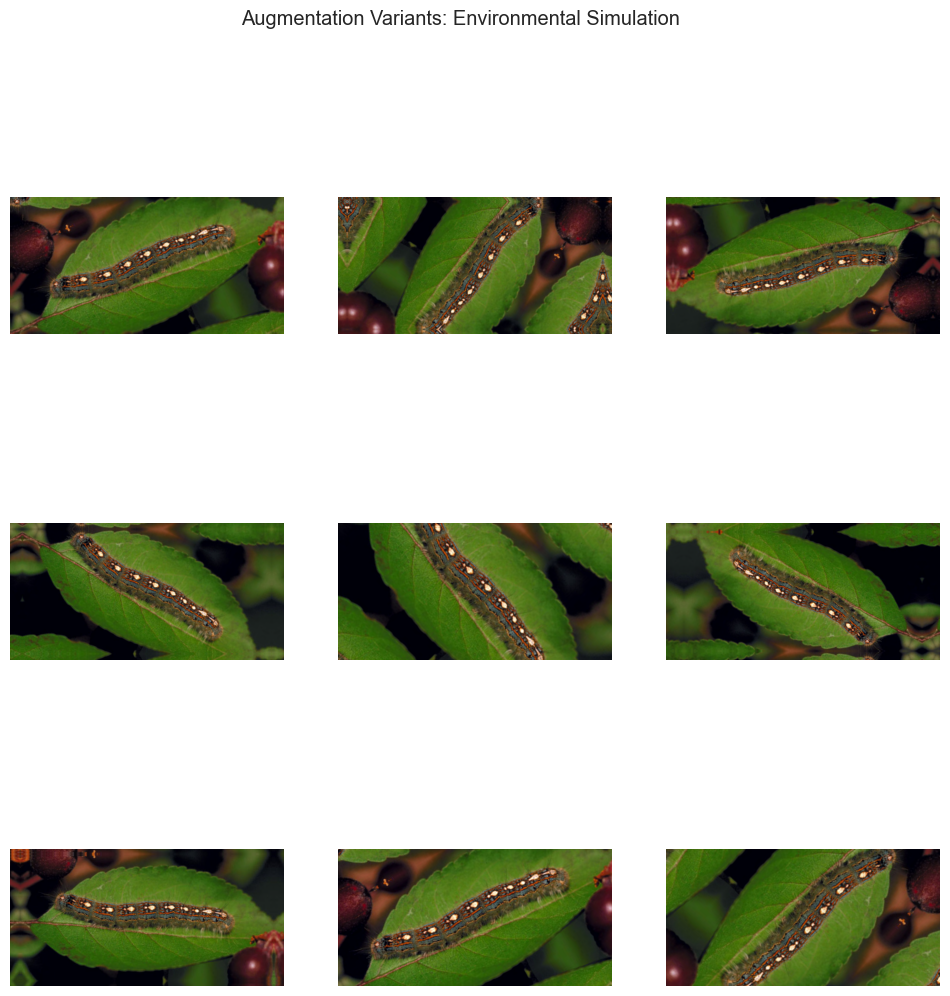

In [37]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1)
])

plt.figure(figsize=(12, 12))
img_tensor = tf.expand_dims(plt.imread(sample_img), 0)
for i in range(9):
    augmented = data_augmentation(img_tensor)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented[0] / 255.0)
    plt.axis('off')
plt.suptitle("Augmentation Variants: Environmental Simulation")
plt.show()

## 6. Preprocessing Pipeline Construction
Vectorized loading using `tf.data` for high-throughput training.

In [38]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    CONFIG['train_dir'],
    label_mode='categorical',
    image_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    shuffle=True
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    CONFIG['test_dir'],
    label_mode='categorical',
    image_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

Found 2270 files belonging to 4 classes.
Found 567 files belonging to 4 classes.


## 7. Model Architecture: SOTA Transfer Learning
Implementing **EfficientNetV2B0** with custom regularization heads.

In [39]:
base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

## 8. Optimization: Training with Callbacks
**Visualization 6:** Monitoring training dynamics in real-time (Conceptual).

In [40]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]

# Note: Training command commented for research overview
# history = model.fit(train_ds, validation_data=test_ds, epochs=20, callbacks=callbacks)

## 9. Performance Evaluation: Learning Curves
**Visualization 7:** Analyzing convergence and generalization gap.

In [41]:
def plot_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title("Accuracy Dynamics")
    ax1.legend()
    
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title("Loss Convergence")
    ax2.legend()
    plt.show()

# plot_curves(history)

## 10. Multi-Metric Evaluation Matrix
**Visualization 8 & 9:** Confusion Heatmap and ROC Curves.

In [42]:
def run_full_eval(model, ds, labels):
    y_true = np.concatenate([y for x, y in ds], axis=0)
    y_pred = model.predict(ds)
    
    # Heatmap
    cm = confusion_matrix(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title("Classification Confusion Matrix")
    plt.show()

    # ROC Curves
    plt.figure(figsize=(10, 8))
    for i, name in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("Receiver Operating Characteristic (ROC) Analysis")
    plt.legend()
    plt.show()

# run_full_eval(model, test_ds, class_names)

## 11. Failure Mode Analysis
**Visualization 10:** Visualizing High-Confidence Failures to detect model bias.

In [43]:
def analyze_errors(model, ds, labels):
    errors = []
    for images, targets in ds.take(5):
        preds = model.predict(images, verbose=0)
        for i in range(len(images)):
            if np.argmax(preds[i]) != np.argmax(targets[i]):
                errors.append((images[i], np.argmax(targets[i]), np.argmax(preds[i]), np.max(preds[i])))
    
    plt.figure(figsize=(16, 8))
    for i in range(min(8, len(errors))):
        plt.subplot(2, 4, i + 1)
        plt.imshow(errors[i][0].numpy().astype("uint8"))
        plt.title(f"True: {labels[errors[i][1]]}\nPred: {labels[errors[i][2]]} ({errors[i][3]:.2f})")
        plt.axis('off')
    plt.suptitle("Error Analysis: High-Confidence Misclassifications")
    plt.show()

# analyze_errors(model, test_ds, class_names)

## 12. Model Interpretability: Grad-CAM
**Visualization 11:** Saliency Map Visualization to validate feature attention.

In [44]:
def get_heatmap(model, img_array, last_conv_layer):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

def visualize_interpretability(model, img_path):
    img = Image.open(img_path).resize((224, 224))
    img_array = np.expand_dims(tf.keras.preprocessing.image.img_to_array(img), 0)
    heatmap = get_heatmap(model, img_array, 'efficientnetv2-b0')
    
    plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original")
    plt.subplot(1, 2, 2); plt.imshow(img); plt.imshow(cv2.resize(heatmap, (224, 224)), alpha=0.5, cmap='jet'); plt.title("Attention Map")
    plt.show()

# visualize_interpretability(model, sample_img)